In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("C:/Users/josem/Downloads/P_Data_Extract_From_World_Development_Indicators (2)/0dcadbc7-bd26-4ddd-9cac-4190ed12a6a0_Data.csv")
df.head(10)

,Country Name,Country Code,Series Name,Series Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],...,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,Albania,ALB,Military expenditure (% of GDP),MS.MIL.XPND.GD.ZS,1.24636024189216,1.30929137475594,1.32003449433204,1.33684292419802,1.38115794211088,1.35000497056322,...,1.16230386432234,1.10358100880452,1.10915100558884,1.16054478505068,1.28080596201472,1.29583570269739,1.24298808396067,1.21098343566728,1.74399167669186,..
1,Albania,ALB,Military expenditure (% of general government ...,MS.MIL.XPND.ZS,3.84384065661926,4.14741288966839,4.26975280105134,4.61292952593064,4.66321103763279,4.73437520175261,...,3.77889251316413,3.78723434007733,3.80346444991409,3.99130087621609,4.40511619586606,3.98075632132468,3.86998513866664,3.97041542821594,5.61952875583332,..
2,Albania,ALB,Armed forces personnel (% of total labor force),MS.MIL.TOTL.TF.ZS,5.13717005098356,3.11413417074067,2.07007907702074,1.70479333642779,1.68531487168875,1.78613955703739,...,0.656344301232692,0.633524160748185,0.660195770052346,0.645800146381367,0.565041583529038,0.591541401612986,..,..,..,..
3,Austria,AUT,Military expenditure (% of GDP),MS.MIL.XPND.GD.ZS,0.98031858008593,0.908240040709509,0.88352783657309,0.913640318789259,0.893480466242935,0.850142574026263,...,0.698116413133988,0.729737691793485,0.757279033702098,0.745028039648345,0.75035965749035,0.884127145088915,0.8736941368808,0.768528566154672,0.844274840737983,..
4,Austria,AUT,Military expenditure (% of general government ...,MS.MIL.XPND.ZS,1.93159028105101,1.76504348593881,1.68193442016185,1.82318437443309,1.65790767717745,1.66192198199585,...,1.36811785600437,1.45739672398483,1.53610008182722,1.52801954740725,1.54167679725207,1.5570304159137,1.55865661676857,1.45560179338752,1.63257715135905,..
5,Austria,AUT,Armed forces personnel (% of total labor force),MS.MIL.TOTL.TF.ZS,1.04290296805035,0.893394996523248,0.874751511158517,0.868059475621829,0.988297293003033,0.996920015611767,...,0.478649862133146,0.49328330912061,0.459750990106597,0.495831220354555,0.475393009561882,0.499147867781372,..,..,..,..
6,Belarus,BLR,Military expenditure (% of GDP),MS.MIL.XPND.GD.ZS,1.34698415075765,1.43829074692244,1.40024580052512,1.29906390002339,1.35822231382833,1.49845313530187,...,1.13806602416355,1.52328091923032,1.37200444073753,1.53799428873681,1.39642297566801,1.40325859867166,1.36528926554311,1.64869313490861,1.79770336310455,..
7,Belarus,BLR,Military expenditure (% of general government ...,MS.MIL.XPND.ZS,..,32.8021248339973,30.938292476754,28.857837181045,29.8461538461539,32.2101090188305,...,27.2462521634935,37.4427876152014,35.1419367340018,40.6400812252922,37.3841079341109,36.8837119483164,37.6294876589379,45.6543192012733,50.5913118885667,..
8,Belarus,BLR,Armed forces personnel (% of total labor force),MS.MIL.TOTL.TF.ZS,1.89162975635352,3.96001473150115,3.8678846359593,3.70894533128142,3.67839880512672,3.68993422238568,...,3.10040403366489,3.05121763912158,3.05217726572964,3.07464063715025,3.08553255495632,3.17250729275094,..,..,..,..
9,Belgium,BEL,Military expenditure (% of GDP),MS.MIL.XPND.GD.ZS,1.34121027642881,1.27650416647228,1.21571220776463,1.21498815616525,1.14927213880449,1.09664118158572,...,0.909284202068915,0.89470623618152,0.883563446003045,0.891358084802809,0.888429380863306,1.01248470692312,1.03872662668212,1.18239642570098,1.21461599569106,..


In [33]:
# Filter for Armed forces personnel data 2022
MiliExp_GDP = df[df['Series Name'] == 'Military expenditure (% of GDP)']
MiliExp_GDP = MiliExp_GDP[['Country Name', '2023 [YR2023]']]

# Clean the data - remove missing values and convert to numeric
MiliExp_GDP = MiliExp_GDP.dropna()
MiliExp_GDP['2023 [YR2023]'] = pd.to_numeric(MiliExp_GDP['2023 [YR2023]'], errors='coerce')
MiliExp_GDP = MiliExp_GDP.dropna()

MiliExp_GDP.head(10)

,Country Name,2023 [YR2023]
0,Albania,1.743992
3,Austria,0.844275
6,Belarus,1.797703
9,Belgium,1.214616
12,Bosnia and Herzegovina,0.808382
15,Bulgaria,1.847373
18,Canada,1.293001
21,China,1.665339
24,Croatia,1.779892
27,Denmark,1.953196


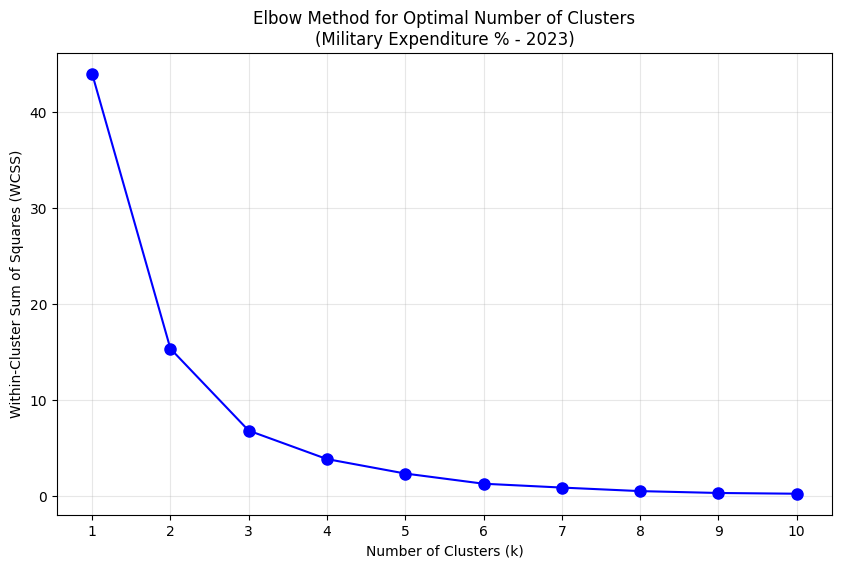

In [39]:
# Prepare data for clustering
X = MiliExp_GDP[['2023 [YR2023]']].values

# Standardize the data (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate WCSS for different numbers of clusters
wcss = []
k_range = range(1, 11)  # Test 1 to 10 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal Number of Clusters\n(Military Expenditure % - 2023)')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.show()

In [45]:

optimal_k = 4

# Perform K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the dataframe
MiliExp_GDP['Cluster'] = clusters
MiliExp_GDP['Cluster_Label'] = MiliExp_GDP['Cluster'].map({0: 'Low', 1: 'Medium', 2: 'High', 3: 'Very High'})

# Get cluster centers in original scale
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

print(f"Cluster Centers (original scale): {cluster_centers_original.flatten()}")

Cluster Centers (original scale): [2.04136691 3.09665669 1.49204593 0.71800717]


In [46]:
# Sort clusters by their center values
sorted_clusters = sorted(
    enumerate(cluster_centers_original.flatten()), 
    key=lambda x: x[1]
)

# Create mapping from cluster number to label
labels = ['Low', 'Medium', 'High', 'Very High']
cluster_label_map = {cluster_num: labels[i] for i, (cluster_num, _) in enumerate(sorted_clusters)}

# Apply the mapping to the dataframe
MiliExp_GDP['Cluster_Label'] = MiliExp_GDP['Cluster'].map(cluster_label_map)

# Now display results
print("="*60)
print("K-MEANS CLUSTERING RESULTS - Military Expenditure % (2023)")
print("="*60)

for cluster_num, center_value in sorted_clusters:
    cluster_data = MiliExp_GDP[MiliExp_GDP['Cluster'] == cluster_num]
    print(f"\nCLUSTER {cluster_num} ({cluster_label_map[cluster_num]}):")
    print(f"Center: {center_value:.2f}%")
    print(f"Number of countries: {len(cluster_data)}")
    print(f"Countries: {', '.join(cluster_data['Country Name'].tolist())}")
    print(f"Range: {cluster_data['2023 [YR2023]'].min():.2f}% to {cluster_data['2023 [YR2023]'].max():.2f}%")
    print(f"Average: {cluster_data['2023 [YR2023]'].mean():.2f}%")

# Summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Total countries analyzed: {len(MiliExp_GDP)}")
print(f"Global average: {MiliExp_GDP['2023 [YR2023]'].mean():.2f}%")
print(f"Global range: {MiliExp_GDP['2023 [YR2023]'].min():.2f}% to {MiliExp_GDP['2023 [YR2023]'].max():.2f}%")


K-MEANS CLUSTERING RESULTS - Military Expenditure % (2023)

CLUSTER 3 (Low):
Center: 0.72%
Number of countries: 6
Countries: Austria, Bosnia and Herzegovina, Luxembourg, Mexico, Moldova, Switzerland
Range: 0.55% to 0.84%
Average: 0.72%

CLUSTER 2 (Medium):
Center: 1.49%
Number of countries: 20
Countries: Albania, Belgium, Canada, China, Czechia, Georgia, Germany, Italy, Kosovo, Montenegro, Portugal, Romania, North Macedonia, Netherlands, Norway, Slovenia, Spain, Sweden, Japan, New Zealand
Range: 1.20% to 1.74%
Average: 1.49%

CLUSTER 0 (High):
Center: 2.04%
Number of countries: 11
Countries: Belarus, Bulgaria, Croatia, Denmark, Finland, France, Hungary, Latvia, Slovak Republic, United Kingdom, Australia
Range: 1.78% to 2.42%
Average: 2.04%

CLUSTER 1 (Very High):
Center: 3.10%
Number of countries: 7
Countries: Estonia, Greece, Lithuania, Poland, Serbia, United States, Korea, Rep.
Range: 2.72% to 3.83%
Average: 3.10%

SUMMARY STATISTICS
Total countries analyzed: 44
Global average: 1.78%

C:\Users\josem\AppData\Local\Temp\ipykernel_42324\3058464224.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cluster_data, labels=cluster_labels)


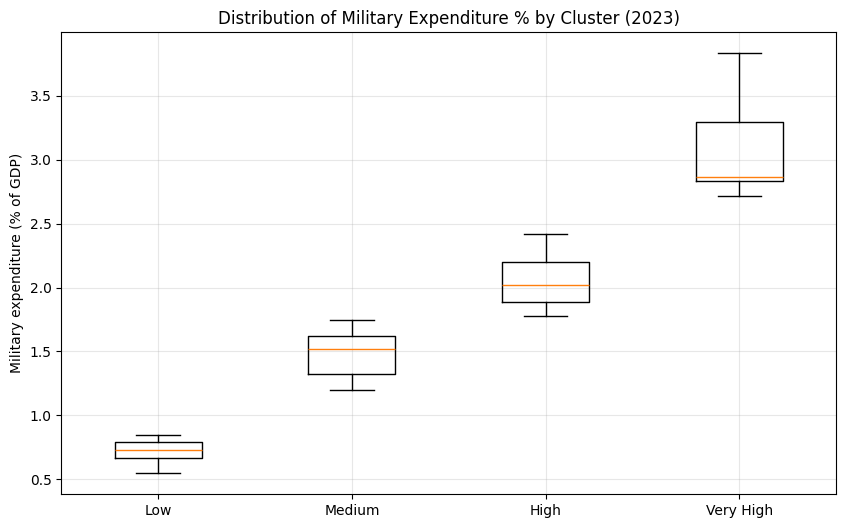

In [43]:
plt.figure(figsize=(10, 6))

# Sort clusters by their actual centers 
sorted_clusters = sorted(
    enumerate(cluster_centers_original.flatten()),
    key=lambda x: x[1]
)

# Prepare data and labels in the correct order
cluster_data = []
cluster_labels = []

for cluster_num, _ in sorted_clusters:
    data = MiliExp_GDP[MiliExp_GDP['Cluster'] == cluster_num]['2023 [YR2023]']
    label = MiliExp_GDP.loc[MiliExp_GDP['Cluster'] == cluster_num, 'Cluster_Label'].iloc[0]
    cluster_data.append(data)
    cluster_labels.append(label)

# Create box plot
plt.boxplot(cluster_data, labels=cluster_labels)
plt.ylabel('Military expenditure (% of GDP)')
plt.title('Distribution of Military Expenditure % by Cluster (2023)')
plt.grid(True, alpha=0.3)
plt.show()
